<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/GPU_Accelerated_Chip_Layout_E_Field_Potential.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

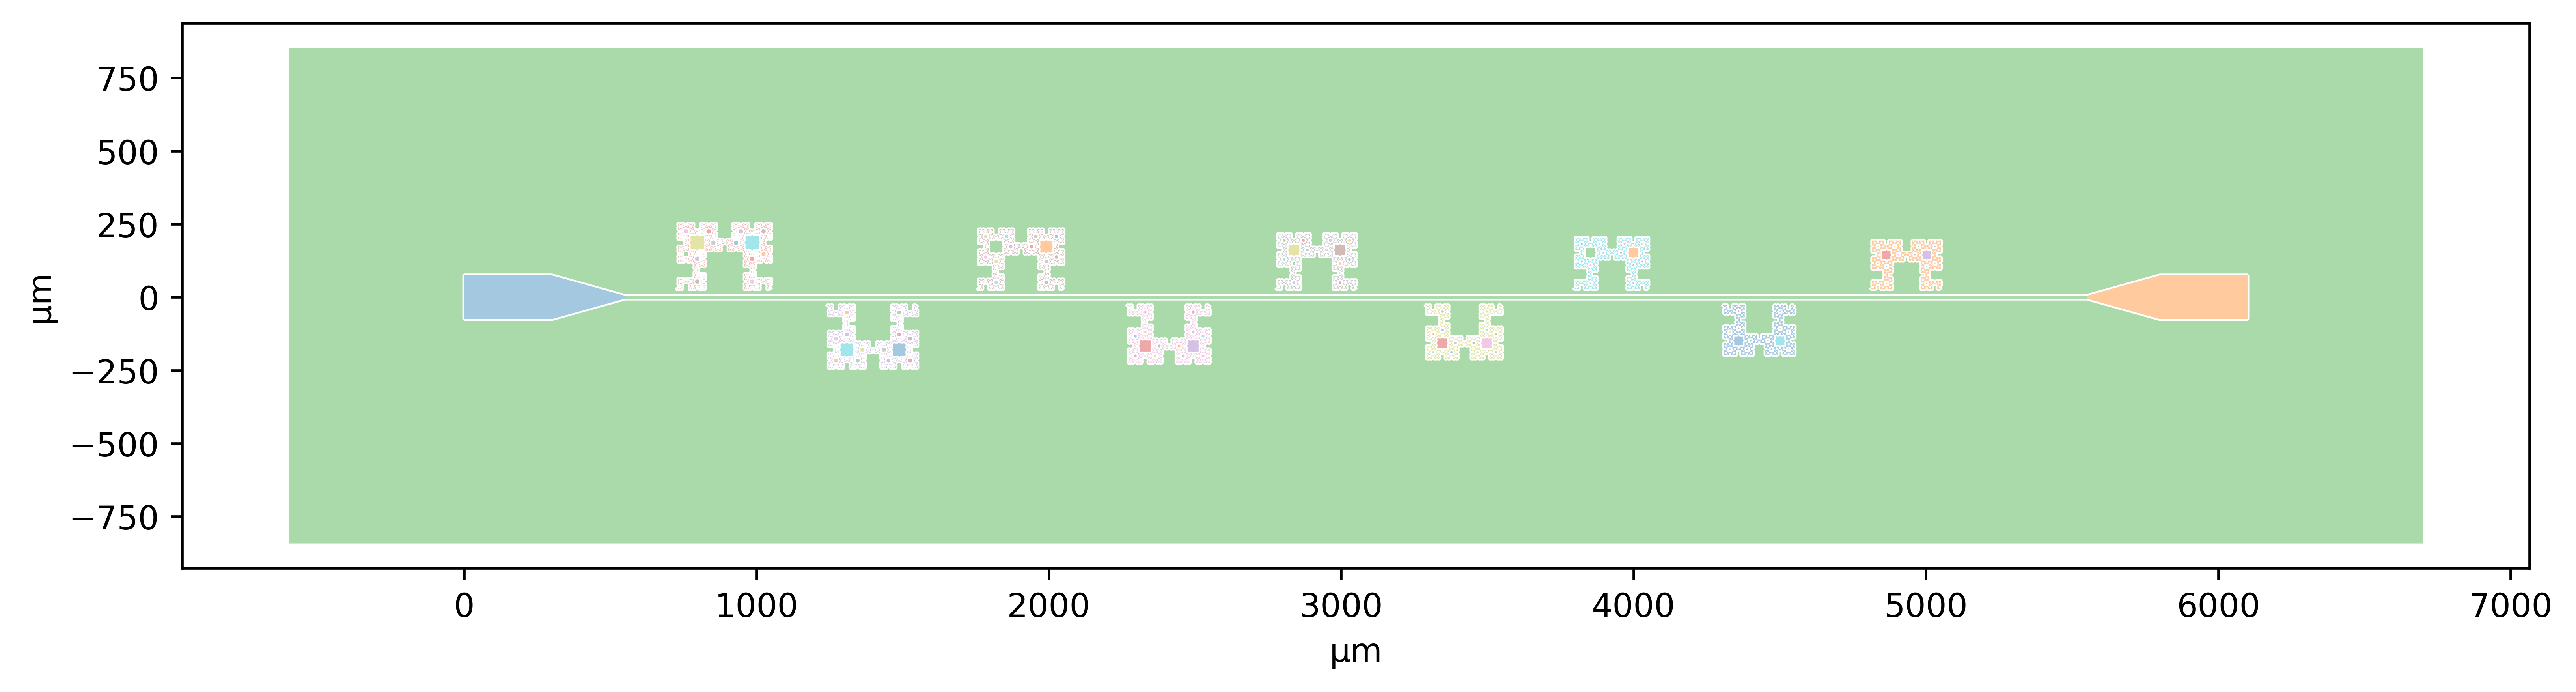


OASIS written to cpw_fibonacci_resonators_v001_calib.oas



In [ ]:
# 1) Quiet installs  (≈ 20 s first run – gdstk needs a wheel)
# ────────────────────────────────────────────────────────────────────
import subprocess, sys, os, numpy as np
def _pip(pkgs): subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install", "--upgrade", *pkgs.split()],
        check=False)

_pip("gdstk  cupy-cuda12x  scipy>=1.13  scikit-image")

# ────────────────────────────────────────────────────────────────────
# 2) Imports  &  SciPy-Array-API flag  (cuFFT dispatch)
# ────────────────────────────────────────────────────────────────────
import cupy as cp
os.environ.setdefault("SCIPY_ARRAY_API", "1")
import scipy.fft as sp_fft        # noqa: F401

import gdstk, matplotlib.pyplot as plt
from skimage.draw import polygon as polyfill

# ────────────────────────────────────────────────────────────────────
# 3)  Build your GDSTK chip (using your v15 script – shortened here)
# ────────────────────────────────────────────────────────────────────


#!/usr/bin/env python3
"""
CPW Feed with Rotated Fibonacci–Fractal λ/4 Metamaterial Resonators
(no IDCs) — v15 • Empirically‑calibrated λ/4 reference

Author   : Onri Jay Benally
Date     : 2025‑06‑19
───────────────────────────────────────────
This variant aligns the layout with Monte‑Carlo by using the
same empirical λ/4 reference length (5 280 µm @ 5 GHz).

Key deltas
─────────────────────
1. **LQ_REF_5GHZ = 5 280 µm**  (0.88× geometric round‑trip)
2. Applies kinetic‑inductance shortening λ′/4 = λ/4 /√(1+L_k/L_g).

Effect
──────
Expect R0 ≈ 5.0 GHz and R8 ≈ 8.0 GHz in the Monte‑Carlo sweep.
"""
import math, warnings
from typing import List, Tuple
import gdstk, numpy as np
from scipy.constants import mu_0
import matplotlib.pyplot as plt; import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 600

# ───────────────────────────── 1)  Knobs ─
FIB_ITER, NUM_RESONATORS = 15, 9
FREQ_MIN, FREQ_MAX = 5.0, 8.0          # GHz design band
LQ_REF_5GHZ = 5280.0                   # µm λ/4 @5 GHz (empirical 0.88×)

W_RES_MIN, W_RES_MAX = 1.0, 3.0        # µm width ramp
GAP_RES = 6.0                          # µm CPW gap

USE_LK, MATERIAL = True, "Nb"
FILM_T_NM, LAMBDA_L0_NM = 80.0, 90.0

# tech dictionary (unchanged)
tech=dict(w_feed=10.0,g_feed=6.0,feed_len=None,w_res=1.0,
          fractal_spacing=20.0,fractal_horz_spacing=500.0,
          pad_len=300.0,pad_wid=150.0,pad_taper_len=250.0,
          sq_margin=50.0,fillet_radius=25.0,g_res=6.0,margin=600.0)
tech["g_max"]=max(tech["g_feed"],tech["g_res"])

FILLET_MIN,FILLET_MAX=0.2,0.6

# Fibonacci word
_DIRECTIONS=np.array([[1,0],[0,1],[-1,0],[0,-1]])

def fib_word(n:int)->str:
    a,b="0","01"
    for _ in range(n-1): a,b=b,b+a
    return b
_WORD=fib_word(FIB_ITER)
_NUM_MOVES=len(_WORD); _NUM_TURNS=_WORD.count("0")
_unit=[np.array([0.,0.])]; cur=0
for idx,ch in enumerate(_WORD):
    if ch=="1": _unit.append(_unit[-1]+_DIRECTIONS[cur])
    else:
        cur=(cur+(1 if idx%2==0 else -1))%4
        _unit.append(_unit[-1]+_DIRECTIONS[cur])
_unit=np.asarray(_unit)

# helpers
rotate90=lambda pts: np.column_stack((-pts[:,1],pts[:,0]))
rect=lambda x0,y0,x1,y1: gdstk.rectangle((x0,y0),(x1,y1))

def preview(cell,figsize=(11,4)):
    fig,ax=plt.subplots(figsize=figsize)
    if hasattr(cell,"plot"): cell.plot(ax)
    else:
        for p in cell.polygons: ax.fill(p.points[:,0],p.points[:,1],alpha=0.4,lw=0.3)
    ax.set_aspect('equal'); ax.set_xlabel('µm'); ax.set_ylabel('µm'); plt.tight_layout(); plt.show()

# electrical helpers
lambda_q=lambda f: LQ_REF_5GHZ*FREQ_MIN/f  # µm prior to kin‑L corr
choose_w=lambda f: W_RES_MIN+(W_RES_MAX-W_RES_MIN)*(f-FREQ_MIN)/(FREQ_MAX-FREQ_MIN)
choose_fil=lambda f: FILLET_MIN+(FILLET_MAX-FILLET_MIN)*(f-FREQ_MIN)/(FREQ_MAX-FREQ_MIN)

def lk_frac(w_um):
    if not USE_LK: return 0.0
    t=80e-9 if MATERIAL.lower()=="nb" else FILM_T_NM*1e-9
    lam=90e-9 if MATERIAL.lower()=="nb" else LAMBDA_L0_NM*1e-9
    w=w_um*1e-6
    Lk=mu_0*lam**2/(w*t)
    k=w/(w+2*GAP_RES*1e-6)
    import mpmath as mp
    Lg=(mu_0/4)*mp.ellipk(1-k**2)/mp.ellipk(k**2)
    return float(Lk/Lg)

def step_len(lq_um,fil,lk):
    lq_eff=lq_um/math.sqrt(1+lk)
    k=(2-math.pi/2)
    return lq_eff/(_NUM_MOVES-_NUM_TURNS*fil*k)

# resonator builder

def build_res(origin,freq,up):
    w=choose_w(freq); fil=choose_fil(freq); lk=lk_frac(w)
    step=step_len(lambda_q(freq),fil,lk)
    pts=rotate90(_unit*step)
    if not up: pts=pts.copy(); pts[:,1]*=-1
    pts+=np.asarray(origin)-pts[0]
    fp=gdstk.FlexPath(pts.tolist(),w,bend_radius=fil*step,simple_path=True)
    return fp.to_polygons()

# chip assembly

def build_chip(p):
    lib=gdstk.Library(unit=1e-6); cell=lib.new_cell('MAIN')
    conductors=[]
    pitch=p['fractal_horz_spacing']; p['feed_len']=(NUM_RESONATORS-1)*pitch+2*pitch
    feed_x0=p['pad_len']+p['pad_taper_len']
    def launch(x,dir):
        w1,w2=p['w_feed'],p['pad_wid']; xt=x+dir*p['pad_taper_len']; xp=xt+dir*p['pad_len']
        return gdstk.Polygon([(x,w1/2),(xt,w2/2),(xp,w2/2),(xp,-w2/2),(xt,-w2/2),(x,-w1/2)])
    cell.add(launch(feed_x0,-1),launch(feed_x0+p['feed_len'],1))
    feed=rect(feed_x0,-p['w_feed']/2,feed_x0+p['feed_len'],p['w_feed']/2); cell.add(feed)
    conductors.extend(cell.polygons)
    start_x=feed_x0+pitch; freqs=np.linspace(FREQ_MIN,FREQ_MAX,NUM_RESONATORS)
    for i,f in enumerate(freqs):
        x=start_x+i*pitch; y_off=p['w_feed']/2+p['g_feed']+p['fractal_spacing']
        y=y_off if i%2==0 else -y_off
        polys=build_res((x,y),f,i%2==0); cell.add(*polys); conductors.extend(polys)
    cu=gdstk.boolean(conductors,[],"or"); xs=np.concatenate([p.points[:,0] for p in cu]); ys=np.concatenate([p.points[:,1] for p in cu])
    frame=rect(xs.min()-p['margin'],ys.min()-p['margin'],xs.max()+p['margin'],ys.max()+p['margin'])
    keep=gdstk.offset(cu,p['g_max']+0.1,join='round') or []
    try: ground=gdstk.boolean(frame,keep,'not') if keep else [frame]
    except: ground=[frame]
    cell.add(*ground)
    return lib

if __name__=='__main__':
    warnings.filterwarnings('ignore',category=RuntimeWarning)
    lib=build_chip(tech); preview(lib.top_level()[0])
    lib.write_oas('cpw_fibonacci_resonators_v001_calib.oas')
    print('\nOASIS written to cpw_fibonacci_resonators_v001_calib.oas\n')

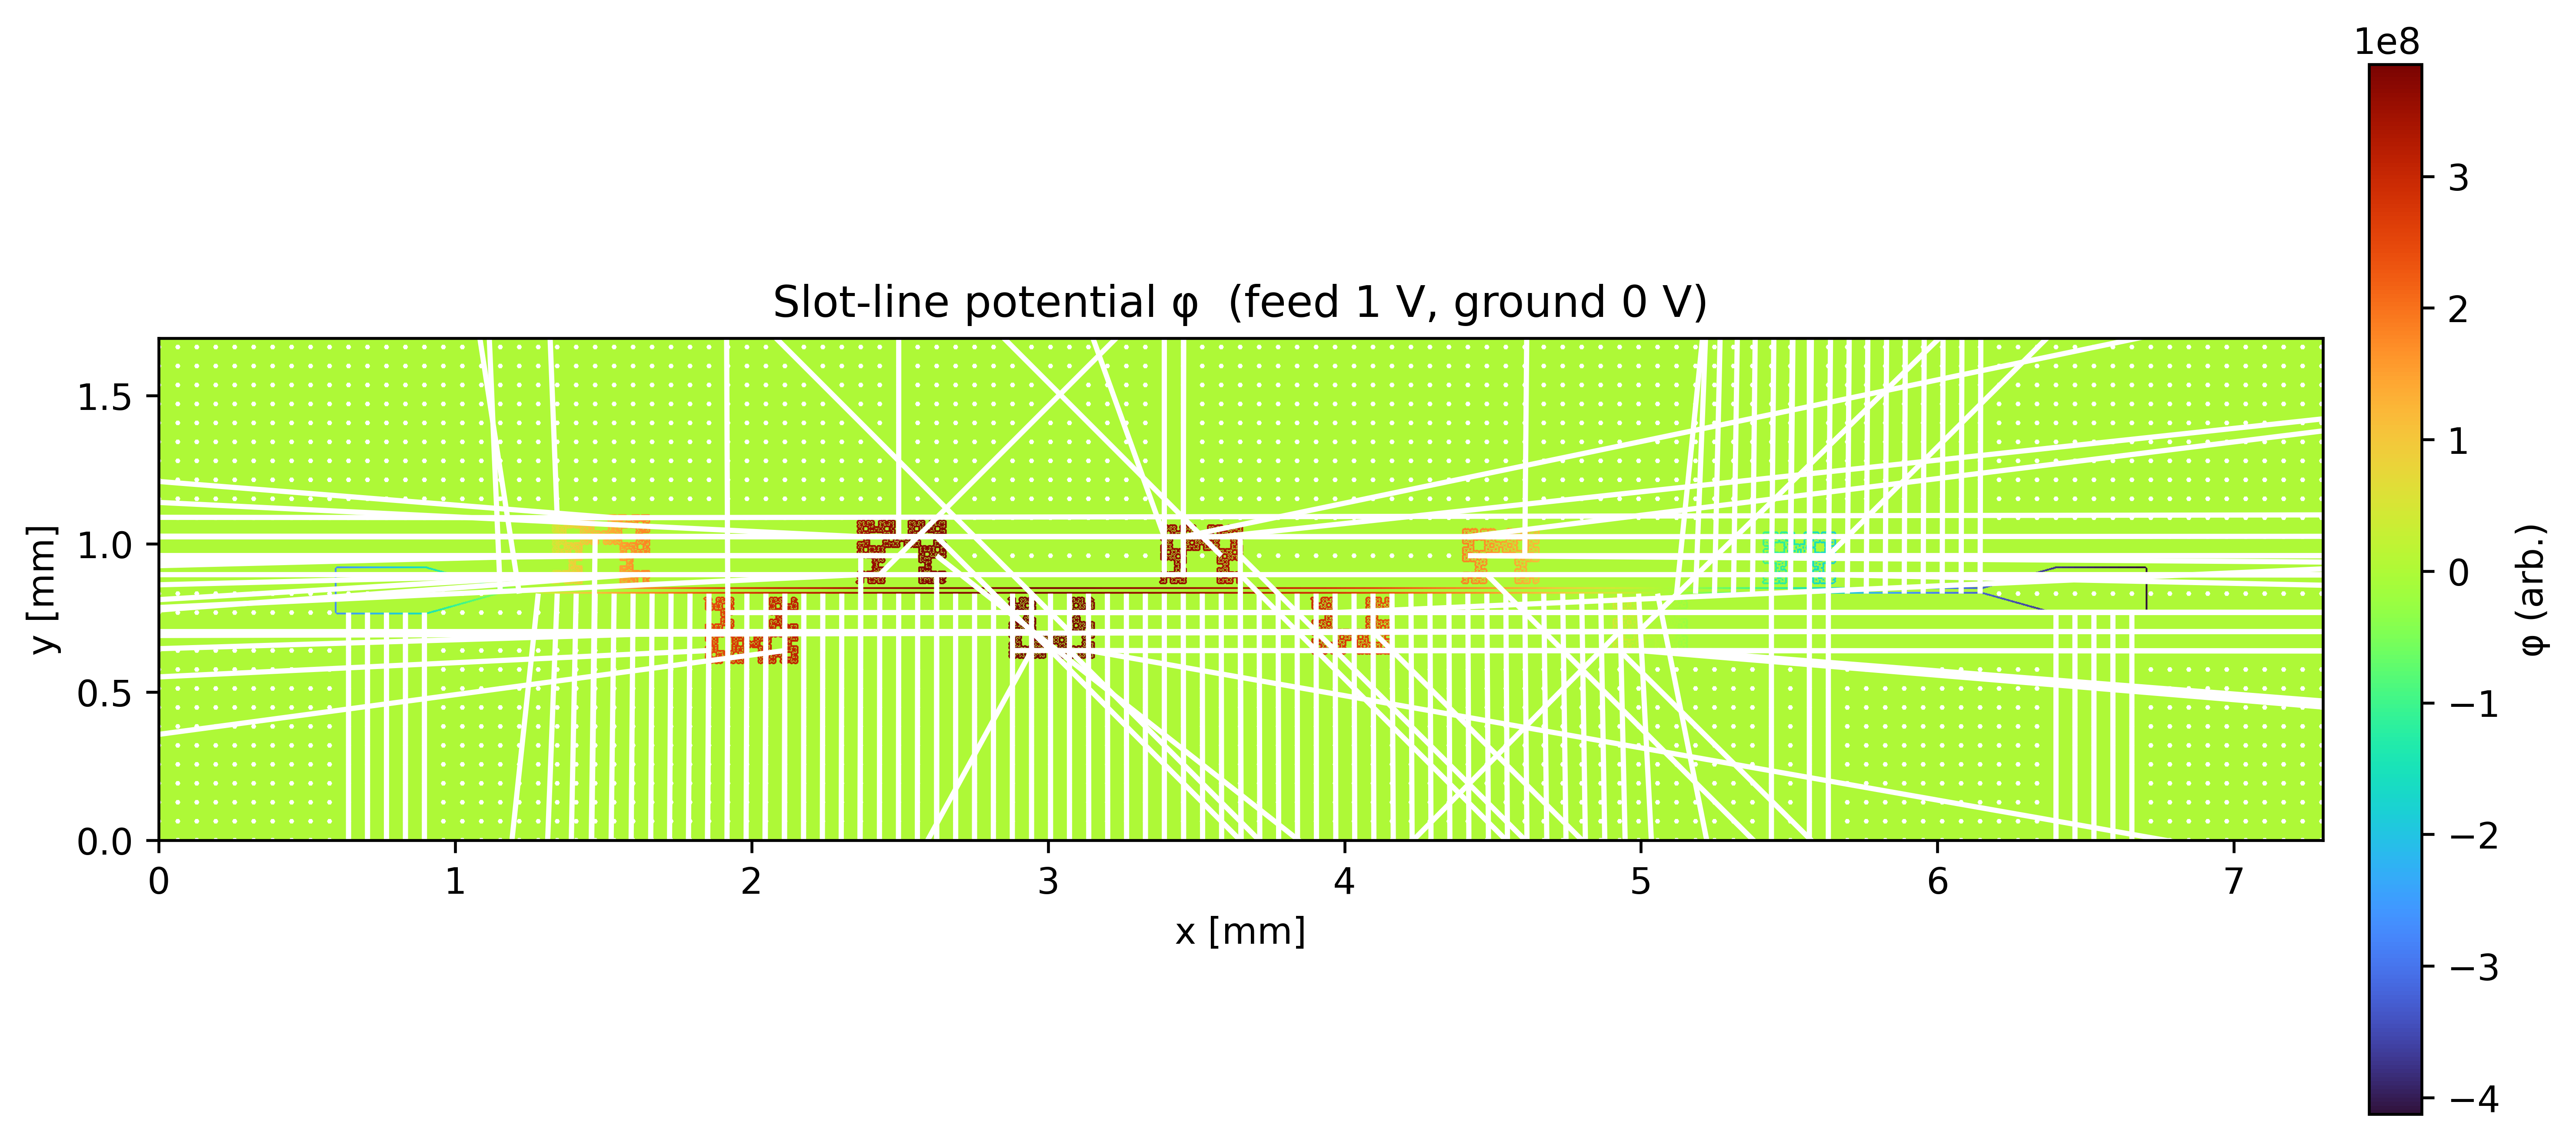

In [ ]:
# ===============================================================
#  GPU electrostatic solve for the GDSTK slot-line layout
#  (feed at 1 V, ground plane at 0 V)   ––  solver + plot
# ===============================================================

# 0) make sure build_chip is imported / executed -----------------
try:
    build_chip
except NameError as err:
    raise RuntimeError(
        "build_chip() is not defined. "
        "Run the layout-generation cell first or import it with "
        "`from my_layout_module import build_chip`."
    ) from err

import numpy as np, cupy as cp, matplotlib.pyplot as plt
from skimage.draw import polygon as polyfill

# ---- 1) Same tech-dict -----------------------------------------
tech = dict(
    w_feed=10.0, g_feed=6.0, feed_len=None,
    w_res=1.0,
    fractal_spacing=20.0, fractal_horz_spacing=500.0,
    pad_len=300.0, pad_wid=150.0, pad_taper_len=250.0,
    sq_margin=50.0, fillet_radius=25.0,
    g_res=6.0, margin=600.0
)
tech["g_max"] = max(tech["g_feed"], tech["g_res"])

chip_lib  = build_chip(tech)
main_cell = chip_lib.top_level()[0]

# ---- 2) Identify feed vs ground polygons -----------------------
feed_polys, ground_polys = [], []
for poly in main_cell.polygons:
    bb = np.asarray(poly.bounding_box())      # tuple → array
    if np.isclose(bb[1,1] - bb[0,1], tech["w_feed"], atol=1e-3):
        feed_polys.append(poly.points.copy())
    else:
        ground_polys.append(poly.points.copy())

# ---- 3) Rasterise to bitmap ------------------------------------
dx = 2.0                                      # µm / pixel
(xmin, ymin), (xmax, ymax) = main_cell.bounding_box()
w_um, h_um = xmax - xmin, ymax - ymin
Nx, Ny = int(np.ceil(w_um/dx)), int(np.ceil(h_um/dx))

phi_bc = np.full((Ny, Nx), np.nan, dtype=np.float32)

def raster(polys, value):
    for pts in polys:
        px = (pts[:,0] - xmin) / dx
        py = (pts[:,1] - ymin) / dx
        rr, cc = polyfill(py, px, (Ny, Nx))
        phi_bc[rr, cc] = value

raster(ground_polys, 0.0)     # ground = 0 V
raster(feed_polys,   1.0)     # feed   = 1 V

# ---- 4) GPU Laplace solve (FFT trick) --------------------------
phi0  = cp.asarray(np.nan_to_num(phi_bc, nan=0.0))
fixed = cp.asarray(~np.isnan(phi_bc))

kx = cp.fft.fftfreq(Nx)*(2*cp.pi/Nx)
ky = cp.fft.fftfreq(Ny)*(2*cp.pi/Ny)
k2 = kx[None,:]**2 + ky[:,None]**2
k2[0,0] = 1.0

rhs = -cp.fft.ifft2(cp.fft.fft2(phi0)*k2).real
rhs *= fixed

phi = cp.real(cp.fft.ifft2(cp.fft.fft2(rhs)/k2))
phi = phi*(~fixed) + phi0
Ey, Ex = cp.gradient(-phi)

# ---- 5) Plot ----------------------------------------------------
phi_h = cp.asnumpy(phi)
Ex_h, Ey_h = cp.asnumpy(Ex), cp.asnumpy(Ey)

fig, ax = plt.subplots(figsize=(10,4.5))
im = ax.imshow(phi_h, origin="lower", cmap="turbo",
               extent=[0, w_um/1e3, 0, h_um/1e3])
ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
ax.set_title("Slot-line potential φ  (feed 1 V, ground 0 V)")

step = 32
Ex_ds, Ey_ds = Ex_h[::step,::step], Ey_h[::step,::step]
x_coords = (np.arange(Ex_ds.shape[1])*step*dx)/1e3
y_coords = (np.arange(Ex_ds.shape[0])*step*dx)/1e3
xs, ys = np.meshgrid(x_coords, y_coords)

ax.quiver(xs, ys, Ex_ds, Ey_ds, color="white",
          scale=100, headwidth=3, headlength=4)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="φ (arb.)")
plt.tight_layout(); plt.show()